<a href="https://colab.research.google.com/github/ceremona/Pulse_pipeline/blob/main/pulse_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pulse-Response Pipeline: NGspice Model, Shared Analysis, and the Siglent Capture Path

Companion to the battery-cycle-life notebook. One analysis pipeline, three data sources, honestly labeled:

- **ngspice-sim** — the fixture modeled in NGspice and run inside this notebook. Ground truth is known because we injected it: the pipeline must recover the ESR and capacitance we put in. This validates the *analysis*, not any measurement.
- **scope-capture** — scripted SCPI captures from a Siglent SDS804X HD over TCP. Tonight this validates the *instrument path* against any bench signal (the calibrator terminal). After the fixture is built, the same cells capture real pulses.
- **synthetic** — toy physics, used only if NGspice is unavailable. Labeled, never mixed.

The architecture point: the NGspice model and the oscilloscope never talk to each other. The notebook is the bridge — both sources produce rows in one schema (source, provenance, retrieval time, QA flags), and SQL does the model-vs-measurement comparison once both exist.

Scope: nothing here is a cell measurement yet. It is a validated pipeline waiting for hardware — exactly the state a model-first bring-up is supposed to be in. Runs end to end with no hardware: Runtime, Run all.

## Vocabulary used here

- **ESR / DCIR** — series (internal) resistance: the instantaneous terminal-voltage step at load onset divided by pulse current. A proper HPPC test pulses in both directions; this is the single-direction simplification.
- **Capacitance from dV/dt** — C = Q / dV: integrate current over the pulse, divide by the voltage drop between zero-current endpoints. The ESR step cancels at the endpoints because no current flows there.
- **Model-first bring-up** — simulate the fixture before building it; the model predicts the measurement; hardware closes the loop by comparing measured vs modeled. Standard test discipline.
- Full battery vocabulary (CE, EOL, HPPC, EIS) lives in the battery-cycle-life notebook.

In [40]:
import subprocess

def have(binary):
    return subprocess.run(['which', binary], capture_output=True).returncode == 0

# NGspice runs INSIDE Colab — no pasting of simulation output, no local tools.
NGSPICE_OK = have('ngspice')
if not NGSPICE_OK:
    print('installing ngspice (one-time, about a minute)...')
    subprocess.run(['apt-get', '-qq', 'update'], capture_output=True)
    subprocess.run(['apt-get', '-qq', 'install', '-y', 'ngspice'], capture_output=True)
    NGSPICE_OK = have('ngspice')
print('ngspice available:', NGSPICE_OK)

ngspice available: True


In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

# --- fixture registry: the single source of truth ---
# The netlist, the synthetic fallback, and the future rig constants all read
# from this cell. Change values here and nowhere else.
FIXTURE = {
    'fixture_id': 'SUPERCAP-PULSE-01',
    'cell_id': 'SUPERCAP-10F',
    'cap_f': 10.0,           # supercapacitance, farads
    'v_start': 2.5,          # initial charge voltage
    'r_esr': 0.030,          # series resistance — the quantity we recover
    'r_load': 2.2,           # load resistor
    'r_ds_on': 0.06,         # Q1 IRLZ44N Rds(on) at 3.3 V gate drive
                             #   (~50-80 mohm; was 0.030 assuming 5 V)
    'r_shunt': 0.1,          # current shunt
    'v_gate': 3.3,           # MCU logic level (Teensy 3.0 / ESP32-WROVER)
    'pulse_on_s': 0.050,     # gate pulse starts
    'pulse_width_s': 0.950,  # gate pulse width
    'datasheet_esr_ohm': 0.030, 'datasheet_esr_tol_pct': 50.0,
    'datasheet_cap_f': 10.0, 'datasheet_cap_tol_pct': 20.0,
}

# --- pipeline thresholds (same spirit as the battery notebook) ---
CURRENT_ONSET_A = 0.5      # |I| above this counts as load applied
ESR_RECOVERY_TOL_PCT = 10.0
CAP_RECOVERY_TOL_PCT = 10.0
BASELINE_STD_MAX_V = 0.003
I_RANGE_A = (0.3, 3.0)

# --- data source switches ---
# None -> run NGspice in Colab (default). Point at an uploaded pulse_sim.csv
# if you ran NGspice locally. Same wrdata layout either way.
SIM_CSV_PATH = None
# None -> hardware path skipped. Set to your scope LAN address to enable it.
SCOPE_IP = None

print('fixture registry ready:', FIXTURE['fixture_id'])

fixture registry ready: SUPERCAP-PULSE-01


## Part A — the model, generated from the fixture registry

The netlist is *generated from the same constants the analysis uses*, so the model cannot drift from the pipeline. Content-identical topology to the hand-written `hppc_lite_fixture.cir`: ideal capacitor + ESR, load resistor, MOSFET switch approximated by a voltage-controlled switch, shunt; gate drive is a delayed 5 V pulse. `wrdata` writes interleaved time/value columns — the parser below expects that layout.

In [42]:
CIR_PATH = 'hppc_lite_fixture.cir'
SIM_OUT = 'pulse_sim.csv'

def build_netlist(fx):
    # Netlist generated from the fixture registry so the model can never drift
    # from the analysis. Node names MATCH THE SCHEMATIC:
    #   CAPH    = cap terminal        (= CH1)
    #   DRN     = R4-to-Q1 node
    #   SRC     = Q1-to-R7 node       (= CH2)
    #   G1      = Q1 gate drive
    #   cap_int = model-internal ideal-cap node (no schematic equivalent)
    #
    # DISCHARGE HALF only. The charge switch (Q2/Q3, R1, R2, R3, R6b, R8) is
    # NOT modeled; the cap is pre-charged via .ic. Valid because Q2 is OFF
    # during the pulse, so the charge branch carries no current. ESR and C
    # recovered by the analysis are independent of the switch Ron and the
    # shunt value — which is why an ideal switch is acceptable here.
    t_on = fx['pulse_on_s']
    w = fx['pulse_width_s']
    v_gate = fx['v_gate']
    r_ds = fx['r_ds_on']
    tstop = t_on + w + 0.1
    lines = [
        '* hppc_lite_fixture.cir — DISCHARGE HALF of the supercap pulse fixture',
        '* Generated from the fixture registry; node names match the schematic.',
        '* Charge switch (Q2/Q3) NOT modeled — cap pre-charged via .ic.',
        '',
        '* gate drive = MCU D9, logic-level step, on at t_on for width w',
        f'V_gate G1 0 PULSE(0 {v_gate} {t_on} 5u 5u {w} 2)',
        '* Q1 IRLZ44N approximated as a switch. Ron reflects Rds(on) at this',
        '* gate voltage; it does not affect ESR or C recovery.',
        f'.model nsw SW(Ron={r_ds} Roff=1e6 Vt=1.5 Vh=0.3)',
        'S1 DRN SRC G1 0 nsw',
        '',
        f'C_cap cap_int 0 {fx["cap_f"]}',
        f'R_esr CAPH cap_int {fx["r_esr"]}',
        f'R_load CAPH DRN {fx["r_load"]}',
        f'R_shunt SRC 0 {fx["r_shunt"]}',
        '',
        f'.ic V(cap_int)={fx["v_start"]}',
        f'.tran 2u {tstop}s 0 1m uic',
        '',
        '.control',
        'run',
        'wrdata pulse_sim.csv v(CAPH) v(SRC) v(cap_int)',
        'quit',
        '.endc',
        '.end',
    ]
    return chr(10).join(lines) + chr(10)

def run_ngspice(netlist_text):
    with open(CIR_PATH, 'w') as fh:
        fh.write(netlist_text)
    if os.path.exists(SIM_OUT):
        os.remove(SIM_OUT)
    try:
        r = subprocess.run(['ngspice', '-b', CIR_PATH], capture_output=True,
                           text=True, timeout=300)
        return (r.returncode == 0 and os.path.exists(SIM_OUT)), r
    except Exception as err:
        return False, err

def parse_wrdata(path):
    # wrdata writes interleaved columns: t, v1, t, v2, t, v3 ...
    # Column order matches the netlist's wrdata line:
    #   col1 = v(CAPH)     -> returned as 'v_cap_h'   (cap terminal, CH1)
    #   col2 = v(SRC)      -> returned as 'v_shunt'   (shunt node, CH2)
    #   col3 = v(cap_int)  -> returned as 'v_cap_int' (model-internal node)
    # Single pass, low memory; tolerates 2-column files (voltage only).
    t_l, v_l, s_l, c_l = [], [], [], []
    with open(path) as fh:
        for line in fh:
            p = line.split()
            if len(p) >= 6:
                t_l.append(float(p[0])); v_l.append(float(p[1]))
                s_l.append(float(p[3])); c_l.append(float(p[5]))
            elif len(p) == 4:
                t_l.append(float(p[0])); v_l.append(float(p[1]))
                s_l.append(float(p[3]))
            elif len(p) == 2:
                t_l.append(float(p[0])); v_l.append(float(p[1]))
    if not t_l:
        raise RuntimeError('empty wrdata file: ' + path)
    t = np.array(t_l)
    v_cap_h = np.array(v_l)
    if s_l:
        v_shunt = np.array(s_l)
    else:
        v_shunt = np.full_like(t, np.nan)
    if c_l:
        v_cap_int = np.array(c_l)
    else:
        v_cap_int = np.full_like(t, np.nan)
    return {'t_s': t, 'v_cap_h': v_cap_h, 'v_shunt': v_shunt, 'v_cap_int': v_cap_int}

def synthetic_pulse(fx, dt=2e-6, noise_v=2e-4, seed=7):
    # Toy physics used ONLY when NGspice and uploaded CSVs are both absent.
    # Reads r_ds_on from the registry, so it tracks the corrected switch value.
    rng = np.random.default_rng(seed)
    r_loop = fx['r_esr'] + fx['r_load'] + fx['r_ds_on'] + fx['r_shunt']
    tau = fx['cap_f'] * r_loop
    t = np.arange(0.0, fx['pulse_on_s'] + fx['pulse_width_s'] + 0.1, dt)
    v_int = np.full_like(t, fx['v_start'])
    i = np.zeros_like(t)
    on = (t >= fx['pulse_on_s']) & (t < fx['pulse_on_s'] + fx['pulse_width_s'])
    v_int[on] = fx['v_start'] * np.exp(-(t[on] - fx['pulse_on_s']) / tau)
    i[on] = v_int[on] / r_loop
    v_cap_h = v_int - i * fx['r_esr'] + noise_v * rng.standard_normal(len(t))
    v_shunt = i * fx['r_shunt'] + noise_v * rng.standard_normal(len(t))
    return {'t_s': t, 'v_cap_h': v_cap_h, 'v_shunt': v_shunt, 'v_cap_int': v_int}

def load_sim():
    stamp = datetime.now(timezone.utc).strftime('%Y-%m-%dT%H:%M:%SZ')
    if SIM_CSV_PATH is not None and os.path.exists(SIM_CSV_PATH):
        data = parse_wrdata(SIM_CSV_PATH)
        data.update(source='ngspice-sim (uploaded csv)',
                    provenance=SIM_CSV_PATH, retrieved_utc=stamp)
    elif NGSPICE_OK:
        ok, r = run_ngspice(build_netlist(FIXTURE))
        if ok:
            data = parse_wrdata(SIM_OUT)
            data.update(source='ngspice-sim (in-colab)',
                        provenance='ngspice -b hppc_lite_fixture.cir',
                        retrieved_utc=stamp)
        else:
            print('ngspice run failed:', str(r)[:300])
            data = synthetic_pulse(FIXTURE)
            data.update(source='synthetic', provenance='synthetic-fallback',
                        retrieved_utc=stamp)
    else:
        data = synthetic_pulse(FIXTURE)
        data.update(source='synthetic', provenance='synthetic-fallback',
                    retrieved_utc=stamp)
    return data

sim = load_sim()
print('sim source:', sim['source'], '| points:', len(sim['t_s']))
print('provenance:', sim['provenance'])

sim source: ngspice-sim (in-colab) | points: 1145
provenance: ngspice -b hppc_lite_fixture.cir


## Part B — the analysis pipeline, lifted verbatim

Both workhorse functions are copied unchanged from the battery-cycle-life notebook. That is deliberate: that notebook proved `dcir_step_estimate` was sparse on NASA data *by recording structure* — cycle files started with the load already applied. Here the recording starts before the load, so the same function returns a value on every pulse. Same code, better data.

Because this is a simulation, the answer is known in advance: ESR = 0.030 ohm and C = 10 F are injected. Recovering them within tolerance is the validation. If the pipeline does not, the bug is in the pipeline, not the physics.

In [43]:
def trapezoid_ah(current_a, t_s):
    # Integrate |I| dt by the trapezoid rule; coulombs to amp-hours.
    # LIFTED VERBATIM from the battery-cycle-life notebook.
    dt = np.diff(t_s)
    if len(dt) == 0:
        return np.nan
    avg = 0.5 * (np.abs(current_a[:-1]) + np.abs(current_a[1:]))
    return float(np.sum(avg * dt) / 3600.0)

def dcir_step_estimate(voltage_v, current_a, onset_a=CURRENT_ONSET_A):
    # Ohmic resistance from the instantaneous voltage step at load onset.
    # LIFTED VERBATIM from the battery-cycle-life notebook — the whole point:
    # on our own fixture the recording starts BEFORE the load, so this
    # returns a value on every pulse instead of being sparse.
    on = np.abs(current_a) > onset_a
    if not np.any(on):
        return np.nan
    idx = int(np.argmax(on))
    if idx == 0 or len(voltage_v) < idx + 3:
        return np.nan
    v_before = float(voltage_v[idx - 1])
    v_after = float(np.median(voltage_v[idx:idx + 3]))
    i_on = float(np.abs(current_a[idx]))
    if v_before <= v_after or i_on <= 0:
        return np.nan
    return (v_before - v_after) / i_on

print('pipeline functions ready (lifted verbatim from the battery notebook)')

pipeline functions ready (lifted verbatim from the battery notebook)


In [44]:
def analyze_pulse(data, fx, source_label):
    # One row of pulse_summary: metrics + QA flags + provenance.
    # Works identically on simulation, synthetic, and (later) scope captures.
    t = np.asarray(data['t_s'])
    v_term = np.asarray(data['v_cap_h'])
    i = np.asarray(data['v_shunt']) / fx['r_shunt']

    on = np.abs(i) > CURRENT_ONSET_A
    if not np.any(on):
        raise RuntimeError('no pulse onset found in capture')
    idx_on = int(np.argmax(on))
    off_rel = np.where(~on[idx_on:])[0]
    idx_off = int(idx_on + off_rel[0]) if len(off_rel) else len(t) - 1

    # baseline: last ~5 ms before onset (pre-load terminal voltage)
    dt = float(np.median(np.diff(t))) if len(t) > 1 else 1e-6
    n_base = max(1, int(0.005 / dt))
    pre = v_term[:idx_on]
    n_base = min(n_base, len(pre))
    baseline = float(np.median(pre[-n_base:]))
    baseline_std = float(np.std(pre[-n_base:]))

    # ESR from the onset step
    esr_est = dcir_step_estimate(v_term, i)
    step_v = float(baseline - v_term[min(idx_on + 2, len(v_term) - 1)])

    # median current across the pulse window (capped at pulse end). With
    # NGspice's adaptive timesteps this spans the full pulse, so it is the
    # mid-pulse current — the right statistic for a sagging pulse.
    seg_hi = min(idx_on + 5000, idx_off)
    i_pulse = float(np.median(i[idx_on:seg_hi])) if seg_hi > idx_on else np.nan

    # charge moved during the pulse, and capacitance from the zero-current
    # endpoints: both baseline and pulse-end carry no current, so the ESR
    # step cancels and the drop is purely capacitive.
    q_ah = trapezoid_ah(i[idx_on:idx_off + 1], t[idx_on:idx_off + 1])
    q_c = q_ah * 3600.0
    cap_drop = baseline - float(v_term[idx_off])
    cap_est = q_c / cap_drop if cap_drop > 0 else np.nan

    esr_inj, cap_inj = fx['r_esr'], fx['cap_f']
    qa_time_ok = bool(np.all(np.diff(t) >= 0))
    qa_baseline_ok = bool(baseline_std <= BASELINE_STD_MAX_V)
    qa_step_ok = bool(np.isfinite(esr_est) and esr_est > 0)
    qa_esr_ok = bool(np.isfinite(esr_est) and
                     100.0 * abs(esr_est - esr_inj) / esr_inj <= ESR_RECOVERY_TOL_PCT)
    qa_current_ok = bool(np.isfinite(i_pulse) and
                         I_RANGE_A[0] <= i_pulse <= I_RANGE_A[1])
    qa_cap_ok = bool(np.isfinite(cap_est) and
                     100.0 * abs(cap_est - cap_inj) / cap_inj <= CAP_RECOVERY_TOL_PCT)
    flags = (int(not qa_time_ok) + int(not qa_baseline_ok) + int(not qa_step_ok) +
             int(not qa_esr_ok) + int(not qa_current_ok) + int(not qa_cap_ok))

    row = {
        'source': source_label, 'fixture_id': fx['fixture_id'], 'cell_id': fx['cell_id'],
        'esr_est_ohm': esr_est, 'esr_injected_ohm': esr_inj,
        'cap_est_f': cap_est, 'cap_injected_f': cap_inj,
        'i_pulse_a': i_pulse, 'q_ah': q_ah,
        'v_baseline_v': baseline, 'step_v': step_v, 'baseline_std_v': baseline_std,
        'qa_time_ok': qa_time_ok, 'qa_baseline_ok': qa_baseline_ok,
        'qa_step_ok': qa_step_ok, 'qa_esr_ok': qa_esr_ok,
        'qa_current_ok': qa_current_ok, 'qa_cap_ok': qa_cap_ok,
        'qa_flags': flags,
        'provenance': data.get('provenance', 'unknown'),
        'retrieved_utc': data.get('retrieved_utc', ''),
    }
    return row

sim_row = analyze_pulse(sim, FIXTURE, sim['source'])
print('source        :', sim_row['source'])
print('ESR recovered :', round(sim_row['esr_est_ohm'], 5), 'ohm | injected:',
      sim_row['esr_injected_ohm'], '| pass:', sim_row['qa_esr_ok'])
print('C recovered   :', round(sim_row['cap_est_f'], 4), 'F | injected:',
      sim_row['cap_injected_f'], '| pass:', sim_row['qa_cap_ok'])
print('I pulse       :', round(sim_row['i_pulse_a'], 3), 'A | step:',
      round(sim_row['step_v'] * 1000.0, 2), 'mV | QA flags:', sim_row['qa_flags'])

source        : ngspice-sim (in-colab)
ESR recovered : 0.03 ohm | injected: 0.03 | pass: True
C recovered   : 10.0005 F | injected: 10.0 | pass: True
I pulse       : 1.026 A | step: 31.38 mV | QA flags: 0


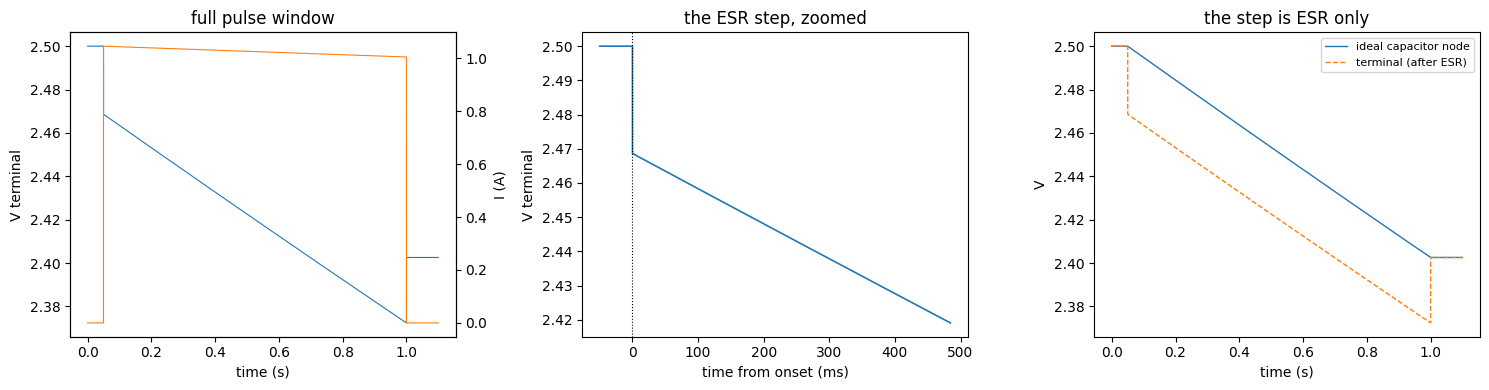

In [45]:
t = sim['t_s']
v_term = sim['v_cap_h']
i_a = sim['v_shunt'] / FIXTURE['r_shunt']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(t, v_term, lw=0.8, color='tab:blue', label='terminal voltage (CH1 analog)')
ax0 = axes[0].twinx()
ax0.plot(t, i_a, lw=0.8, color='tab:orange', label='current (CH2 analog)')
axes[0].set_xlabel('time (s)'); axes[0].set_ylabel('V terminal')
ax0.set_ylabel('I (A)')
axes[0].set_title('full pulse window')

on = np.abs(i_a) > CURRENT_ONSET_A
idx_on = int(np.argmax(on))
lo = max(0, idx_on - 300)
hi = min(len(t), idx_on + 500)
axes[1].plot((t[lo:hi] - t[idx_on]) * 1e3, v_term[lo:hi], lw=1.2)
axes[1].axvline(0, color='k', ls=':', lw=0.8)
axes[1].set_xlabel('time from onset (ms)')
axes[1].set_ylabel('V terminal')
axes[1].set_title('the ESR step, zoomed')

if np.isfinite(sim['v_cap_int']).all():
    axes[2].plot(t, sim['v_cap_int'], lw=1.0, label='ideal capacitor node')
    axes[2].plot(t, v_term, lw=1.0, ls='--', label='terminal (after ESR)')
    axes[2].set_xlabel('time (s)'); axes[2].set_ylabel('V')
    axes[2].set_title('the step is ESR only')
    axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Part C — the Siglent path (real hardware, when present)

To be precise about the interface: **NGspice does not connect to the scope, and the scope does not ingest simulations.** The scope is a second, independent data source. The bridge is the shared schema — a capture and a simulation both become a dict with `t_s`, `v_cap_h`, `v_shunt`, plus `source` and `provenance` — so the same `analyze_pulse` cell runs on either.

The driver is SCPI over a plain TCP socket on port 5025 — no VISA, no drivers. Two caveats (handled in code): this scope family has a documented quirk where waveform replies are prefixed with `C1:WF` before the IEEE 488.2 block (the block reader strips everything before the first `#`), and the preamble format is the one genuinely firmware-dependent piece — so the driver ships with `diagnose()`, which prints the raw material needed to lock the decoder on first contact with the Siglent.

With no fixture: probe the compensation terminal, single-shot trigger, run `diagnose()`, then one capture. If the decoded square wave is clean, the whole instrument path — connect, arm, transfer, decode, convert to volts — is validated. The rig changes the *physics* on CH1/CH2 later; it does not change this code.

In [46]:
import socket

class SiglentScope:
    # Thin SCPI-over-raw-TCP driver for the SDS800X HD. Port 5025, no VISA.
    # Commands follow the official programming guide: WAVeform:SOURce/STARt/
    # INTerval/POINt/WIDth/BYTeorder/PREamble/DATA, TRMD SINGLE to arm.
    # FIRST RUN against hardware: call diagnose() and read the output — the
    # preamble format is the firmware-dependent piece this is built to resolve.
    NL = chr(10)

    def __init__(self, ip, port=5025, timeout=15.0):
        self.ip = ip
        self.sock = socket.create_connection((ip, port), timeout=timeout)
        self.cmd('CHDR OFF')

    def cmd(self, c):
        self.sock.sendall((c + self.NL).encode('ascii'))

    def query_line(self, c, max_chars=200000):
        self.cmd(c)
        buf = bytearray()
        while len(buf) < max_chars:
            ch = self.sock.recv(1)
            if not ch or ch[0] == 10:
                break
            buf += ch
        return buf.decode('ascii', errors='replace').strip()

    def drain(self, quiet=0.3):
        # Eat any trailing terminator bytes so the next query stays in sync.
        old = self.sock.gettimeout()
        self.sock.settimeout(quiet)
        try:
            while True:
                if not self.sock.recv(4096):
                    break
        except socket.timeout:
            pass
        self.sock.settimeout(old)

    def read_block(self, c, max_bytes=8000000):
        # Read an IEEE 488.2 block, stripping any prefix (the documented
        # C1:WF-style prefixes) before the first # character.
        self.cmd(c)
        buf = bytearray()
        while len(buf) < max_bytes:
            chunk = self.sock.recv(65536)
            if not chunk:
                break
            buf += chunk
            i = buf.find(b'#')
            if i != -1 and len(buf) >= i + 2:
                ndig = buf[i + 1] - 48
                if len(buf) >= i + 2 + ndig:
                    total = int(buf[i + 2:i + 2 + ndig].decode('ascii'))
                    if len(buf) >= i + 2 + ndig + total:
                        payload = buf[i + 2 + ndig:i + 2 + ndig + total]
                        return bytes(payload)
        raise RuntimeError('no IEEE 488.2 block in reply to ' + c)

    def preamble(self, ch='C1'):
        # Classic Siglent ASCII preamble: xinc,yinc,yref,yorg(,fract).
        # If your firmware returns a binary WAVEDESC instead, this returns
        # None and capture() tells you to run diagnose().
        self.cmd('WAV:SOUR ' + ch)
        resp = self.query_line('WAV:PRE?')
        vals = []
        for tok in resp.split(','):
            try:
                vals.append(float(tok))
            except ValueError:
                return None
        if len(vals) >= 4:
            return {'xinc': vals[0], 'yinc': vals[1],
                    'yref': vals[2], 'yorg': vals[3]}
        return None

    def capture(self, ch='C1', width='WORD', interval=1, start=0, points=250000):
        # Arm happens separately (TRMD SINGLE). This pulls the stopped
        # waveform and converts counts to volts: V = (code - yref) * yinc + yorg.
        pre = self.preamble(ch)
        if pre is None:
            raise RuntimeError('preamble not ASCII-parseable; run diagnose() first')
        self.cmd('WAV:SOUR ' + ch)
        self.cmd('WAV:STAR ' + str(start))
        self.cmd('WAV:INT ' + str(interval))
        self.cmd('WAV:POIN ' + str(points))
        self.cmd('WAV:WID ' + width)
        self.cmd('WAV:BYT LSB')
        payload = self.read_block('WAV:DAT?')
        self.drain()
        if width == 'WORD':
            usable = payload[:(len(payload) // 2) * 2]
            counts = np.frombuffer(usable, dtype='<i2')
        else:
            counts = np.frombuffer(payload, dtype='u1')
        volts = (counts.astype(float) - pre['yref']) * pre['yinc'] + pre['yorg']
        t = pre['xinc'] * np.arange(len(volts))
        return {'volts': volts, 't_s': t, 'pre': pre, 'n': len(volts)}

    def diagnose(self, ch='C1'):
        # First-contact forensics. Paste this output upstream if anything
        # in decode looks wrong — it contains everything needed to fix it.
        print('IDN    :', self.query_line('*IDN?'))
        for q in ('C1:VDIV?', 'C1:OFST?', 'TDIV?', 'SARA?'):
            print(q, ':', self.query_line(q))
        self.cmd('WAV:SOUR ' + ch)
        pre = self.query_line('WAV:PRE?')
        print('WAV:PRE? first 120 chars:', repr(pre[:120]) if pre else 'EMPTY')
        self.cmd('WAV:SOUR ' + ch)
        self.cmd('WAV:WID WORD')
        payload = self.read_block('WAV:DAT?')
        self.drain()
        print('WAV:DAT? block bytes :', len(payload))
        print('first 16 bytes hex   :', payload[:16].hex(' '))
        return payload[:16]

print('SiglentScope driver ready (inert until SCOPE_IP is set)')

SiglentScope driver ready (inert until SCOPE_IP is set)


In [47]:
import time

def scope_session():
    if SCOPE_IP is None:
        print('SCOPE_IP is None — hardware path skipped.')
        print('To validate the driver:')
        print('  1. connect the scope to LAN, find its IP (Utility, LAN)')
        print('  2. probe the compensation terminal on CH1, set edge trigger')
        print('  3. set SCOPE_IP in the config cell, re-run')
        print('The simulation pipeline above runs with no hardware.')
        return None
    try:
        scope = SiglentScope(SCOPE_IP)
    except Exception as err:
        print('could not connect to', SCOPE_IP, ':', err)
        return None
    print('connected:', scope.query_line('*IDN?'))
    return scope

scope = scope_session()
if scope is not None:
    scope.diagnose()
    try:
        scope.cmd('TRMD SINGLE')
        time.sleep(2.0)  # let it trigger
        shot = scope.capture('C1')
        v = shot['volts']
        vpp = float(np.max(v) - np.min(v))
        mid = 0.5 * (np.max(v) + np.min(v))
        cross = np.where(np.diff(np.signbit(v - mid)))[0]
        freq = np.nan
        if len(cross) > 2 and shot['pre']['xinc'] > 0:
            period = 2.0 * float(np.mean(np.diff(cross))) * shot['pre']['xinc']
            freq = 1.0 / period if period > 0 else np.nan
        print('decoded points:', len(v), '| Vpp (V):', round(vpp, 4),
              '| est freq (Hz):', round(freq, 1) if freq == freq else 'n/a')
        plt.figure(figsize=(9, 3))
        plt.plot(shot['t_s'], v, lw=0.8)
        plt.xlabel('time (s)'); plt.ylabel('CH1 (V)')
        plt.title('decoded CH1 capture — driver validation shot')
        plt.tight_layout(); plt.show()
    except Exception as err:
        print('capture failed:', err)
        print('check: scope triggered and stopped, probe on a live signal')

SCOPE_IP is None — hardware path skipped.
To validate the driver tonight:
  1. connect the scope to LAN, find its IP (Utility, LAN)
  2. probe the compensation terminal on CH1, set edge trigger
  3. set SCOPE_IP in the config cell, re-run
The simulation pipeline above runs with no hardware at all.


## Part D — one table, three sources, SQL on top

Every run appends a row to `pulse_summary`: metrics, injected (model) values, per-check QA booleans, a flag count, provenance, and retrieval time. The `source` column is  — an `ngspice-sim` row can never masquerade as a capture, because the schema itself carries the label. Queries: (1) recovery table per source; (2) model-vs-measurement, which stays empty until a scope capture exists.

In [48]:
import duckdb
Q = chr(39)  # single quote kept as a variable so SQL literals stay clean

pulse_summary = pd.DataFrame([sim_row])
con = duckdb.connect()
con.register('pulse_summary', pulse_summary)

sql1 = ('SELECT source, fixture_id, '
        'ROUND(esr_est_ohm, 5) AS esr_est_ohm, '
        'ROUND(esr_injected_ohm, 5) AS esr_model_ohm, '
        'ROUND(cap_est_f, 4) AS cap_est_f, '
        'ROUND(cap_injected_f, 2) AS cap_model_f, '
        'ROUND(i_pulse_a, 3) AS i_pulse_a, qa_flags '
        'FROM pulse_summary ORDER BY source')
print(con.execute(sql1).fetchdf())

sql2 = ('SELECT fixture_id, '
        'MAX(CASE WHEN source LIKE ' + Q + 'ngspice%' + Q + ' THEN esr_est_ohm END) AS model_esr_ohm, '
        'MAX(CASE WHEN source LIKE ' + Q + 'scope%' + Q + ' THEN esr_est_ohm END) AS measured_esr_ohm, '
        'MAX(CASE WHEN source LIKE ' + Q + 'scope%' + Q + ' THEN cap_est_f END) AS measured_cap_f '
        'FROM pulse_summary GROUP BY fixture_id')
print(con.execute(sql2).fetchdf())
print('model-vs-measurement populates only after a scope capture exists')

                   source         fixture_id  esr_est_ohm  esr_model_ohm  \
0  ngspice-sim (in-colab)  SUPERCAP-PULSE-01         0.03           0.03   

   cap_est_f  cap_model_f  i_pulse_a  qa_flags  
0    10.0005         10.0      1.026         0  
          fixture_id  model_esr_ohm  measured_esr_ohm  measured_cap_f
0  SUPERCAP-PULSE-01           0.03               NaN             NaN
model-vs-measurement populates only after a scope capture exists


In [49]:
# OPTIONAL: mirror pulse_summary into BigQuery.
PROJECT_ID = 'your-project-id'
try:
    from google.cloud import bigquery
    client = bigquery.Client(project=PROJECT_ID)
    table_id = PROJECT_ID + '.battery_test.pulse_summary'
    job = client.load_table_from_dataframe(pulse_summary, table_id)
    job.result()
    print('loaded', len(pulse_summary), 'rows to', table_id)
except Exception as err:
    print('BigQuery skipped (optional):', err)

BigQuery skipped (optional): ("Failed to retrieve http://metadata.google.internal/computeMetadata/v1/instance/service-accounts/default/?recursive=true from the Google Compute Engine metadata service. Status: 404 Response:\nb''", <google.auth.transport.requests._Response object at 0x7a263290cf30>)


## Limitations, roadmap

**Stated plainly:**
- The NGspice run is noise-free, so the baseline-stability check is trivially true there.
- The scope decoder is written against documented commands and the known prefix quirk, but it has not run against firmware. First contact is what `diagnose()` is for.
- No cell was measured in this notebook. The rig — fixture, Arduino pulse controller, CH1/CH2 captures feeding `analyze_pulse`.

**current state:**
> Modeled a supercapacitor pulse-test fixture in NGspice and built the pulse-response analysis pipeline (ESR from voltage step, capacitance from coulomb integration), validated by recovery of injected ground-truth parameters; SCPI capture path for a Siglent SDS804X HD included.

**upgrade to:**
> Designed and built an instrumented supercapacitor pulse-test fixture (supercapacitor, MOSFET switching, shunt sensing) with scripted SCPI capture; measured ESR and capacitance from pulse response, compared against NGspice model predictions and datasheet values.


**Roadmap:** Arduino pulse controller over serial (charge interlock, fire command) — arm scope, fire, capture CH1/CH2, run `analyze_pulse`, append the `scope-capture` row, re-run the model-vs-measurement query.